# Język Python w Analizie Danych
# Lab05 - Zadania praktyczne - Sprawozdanie

Autor: Piotr Przymus 127902

In [25]:
# Import modułów

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# Wczytanie danych
df_csv = pd.read_csv('data/data05.csv')
df_csv.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019.0,Phishing,Education,80.53,773169.0,Hacker Group,Unpatched Software,VPN,63.0
1,China,2019.0,Ransomware,Retail,62.19,295961.0,Hacker Group,Unpatched Software,Firewall,71.0
2,India,2017.0,Man-in-the-Middle,IT,38.65,605895.0,Hacker Group,Weak Passwords,VPN,20.0
3,UK,2024.0,Ransomware,Telecommunications,41.44,659320.0,Nation-state,NaN,AI-based Detection,7.0
4,Germany,2018.0,Man-in-the-Middle,IT,74.41,810682.0,Insider,Social Engineering,VPN,68.0


### Zadanie 1
Dokonałem podstawowej eksploracyjnej analizy danych. Przedstawiłem swoje wnioski dotyczące dostarczonych danych i odpowiedziałem na pytania poniżej popierając się danymi analitycznymi.

In [26]:
# TODO: EDA
print(df_csv.shape)
display(df_csv.head())
df_csv.info()
display(df_csv.describe())

(3000, 10)


,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019.0,Phishing,Education,80.53,773169.0,Hacker Group,Unpatched Software,VPN,63.0
1,China,2019.0,Ransomware,Retail,62.19,295961.0,Hacker Group,Unpatched Software,Firewall,71.0
2,India,2017.0,Man-in-the-Middle,IT,38.65,605895.0,Hacker Group,Weak Passwords,VPN,20.0
3,UK,2024.0,Ransomware,Telecommunications,41.44,659320.0,Nation-state,NaN,AI-based Detection,7.0
4,Germany,2018.0,Man-in-the-Middle,IT,74.41,810682.0,Insider,Social Engineering,VPN,68.0


<class 'pandas.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Country                              2904 non-null   str    
 1   Year                                 2916 non-null   float64
 2   Attack Type                          2905 non-null   str    
 3   Target Industry                      2909 non-null   str    
 4   Financial Loss (in Million $)        2909 non-null   float64
 5   Number of Affected Users             2912 non-null   float64
 6   Attack Source                        2904 non-null   str    
 7   Security Vulnerability Type          2909 non-null   str    
 8   Defense Mechanism Used               2932 non-null   str    
 9   Incident Resolution Time (in Hours)  2914 non-null   float64
dtypes: float64(4), str(6)
memory usage: 234.5 KB


,Year,Financial Loss (in Million $),Number of Affected Users,Incident Resolution Time (in Hours)
count,2916.000000,2909.000000,2912.000000,2914.000000
mean,2019.588820,50.546930,504563.997940,36.507893
std,2.855947,28.692721,289991.034064,20.527897
min,2015.000000,0.500000,424.000000,1.000000
25%,2017.000000,25.850000,255660.250000,19.000000
50%,2020.000000,51.050000,503970.000000,37.000000
75%,2022.000000,75.510000,758088.500000,54.000000
max,2024.000000,99.990000,999635.000000,72.000000


- Dane są w formacie .csv.
- Zbiór danych składa się z 10 atrybutów i ma łącznie 3000 przykładów.
- Zawiera zarówno atrybuty nominalne (`Country`, `Attack Type`, `Target Industry`, `Attack Source`, `Security Vulnerability Type`, `Defense Mechanism Used`), jak i numeryczne (`Year`, `Financial Loss (in Million $)`, `Number of Affected Users`, `Incident Resolution Time (in Hours)`).
- Dla każdego z atrybutów występują braki danych.

### Jaki sektor jest najbardziej narażony na ataki hackerskie? Jak prezentuje się ryzyko w innych sektorach?

Top 5 sektorów pod względem liczby incydentów:
 Target Industry
IT            466
Banking       431
Healthcare    413
Retail        409
Education     406
Name: count, dtype: int64

Top 5 sektorów pod względem sumy strat (mln $):
 Target Industry
IT            22967.68
Banking       21513.10
Retail        19819.72
Government    19817.69
Healthcare    19614.42
Name: Financial Loss (in Million $), dtype: float64


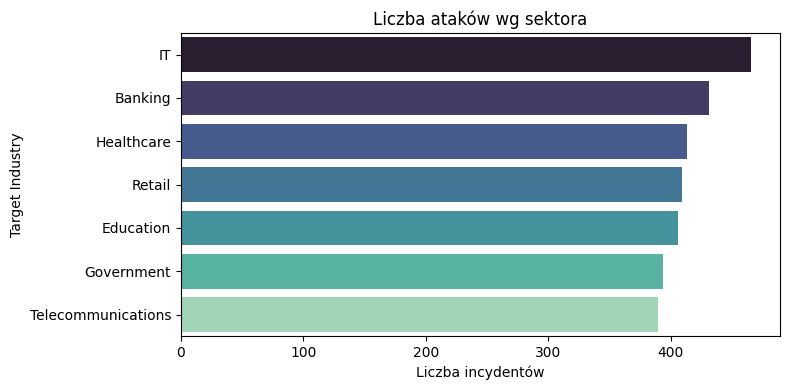

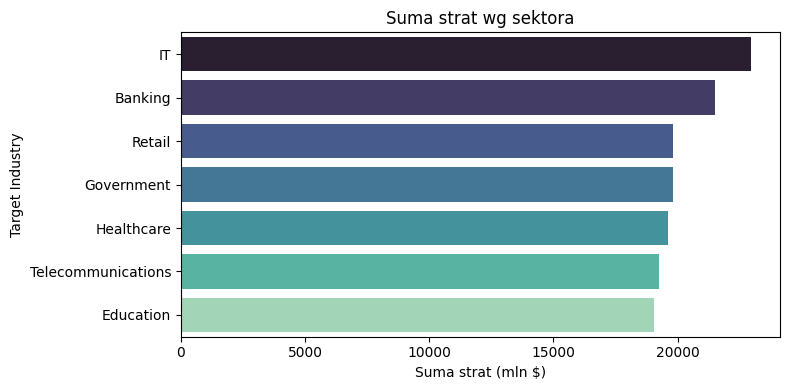

In [27]:
sector_counts = df_csv['Target Industry'].value_counts()
sector_loss = df_csv.groupby('Target Industry')['Financial Loss (in Million $)'].sum().sort_values(ascending=False)
print('Top 5 sektorów pod względem liczby incydentów:\n', sector_counts.head())
print('\nTop 5 sektorów pod względem sumy strat (mln $):\n', sector_loss.head())
plt.figure(figsize=(8,4))
sns.barplot(x=sector_counts.values, y=sector_counts.index, palette='mako', hue=sector_counts.index, legend=False)
plt.xlabel('Liczba incydentów')
plt.title('Liczba ataków wg sektora')
plt.tight_layout()
plt.show()
plt.figure(figsize=(8,4))
sns.barplot(x=sector_loss.values, y=sector_loss.index, palette='mako', hue=sector_loss.index, legend=False)
plt.xlabel('Suma strat (mln $)')
plt.title('Suma strat wg sektora')
plt.tight_layout()
plt.show()

- Najwięcej ataków hackerskich wystąpiło w sektorze IT (466) - zatem to on jest najbardziej narażony na takie ataki.
Wysoką liczbę incydentów zaobserwowano również w sektorach: `Banking`, `Healthcare`, `Retail` oraz `Education`.
- Dodatkowo zauważyłem, że mimo że sektor `Education` ma dość dużą liczbę incydentów, to suma strat finansowych jest trochę niższa niż w niektórych sektorach w których jest ich mniej (np. `Government`, `Telecommunications`). Może to sugerować, że ataki na sektor edukacyjny są częstsze, ale mają mniejszą skalę finansową.

### W którym kraju odnotowano największe straty przez ataki? Jaki jest stosunek tej wartości względem pozostałych strat z innych krajów?

Kraje wg sumy strat (mln $):
 Country
UK           15214.23
Brazil       15031.57
Japan        14744.78
Germany      14565.57
Australia    14492.29
USA          14159.71
France       14092.49
Russia       13694.29
India        13243.81
China        12882.19
Name: Financial Loss (in Million $), dtype: float64

Udział kraju z największą sumą strat w całości strat:
10.71 %


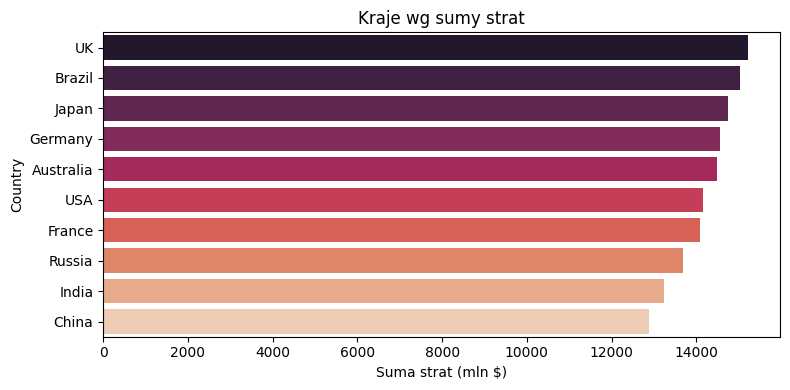

In [28]:
country_loss = df_csv.groupby('Country')['Financial Loss (in Million $)'].sum().sort_values(ascending=False)
print('Kraje wg sumy strat (mln $):\n', country_loss)
total = country_loss.sum()
print('\nUdział kraju z największą sumą strat w całości strat:')
print((country_loss.iloc[0] / total * 100).round(2), '%')
plt.figure(figsize=(8,4))
sns.barplot(x=country_loss.values, y=country_loss.index, palette='rocket', hue=country_loss.index, legend=False)
plt.xlabel('Suma strat (mln $)')
plt.title('Kraje wg sumy strat')
plt.tight_layout()
plt.show()

- Największe straty finansowe spowodowane atakami odnotowano w Wielkiej Brytanii, gdzie łączna wartość strat wyniosła około 15,2 miliardów dolarów.
- Kolejne miejsca zajmują Brazylia, Japonia oraz Niemcy, jednak różnice pomiędzy czołowymi krajami nie są bardzo duże.
- Wielka Brytania odpowiada za około 10.71% wszystkich strat finansowych odnotowanych w zbiorze danych.
- Rozkład strat pomiędzy krajami jest stosunkowo wyrównany - nie ma jednego kraju, który znacząco przewyższa inne pod względem strat finansowych. Problem ataków dotyczy wielu państw w podobnym stopniu.

### Jakich ataków było najwięcej, a jakich najmniej na przestrzeni lat?

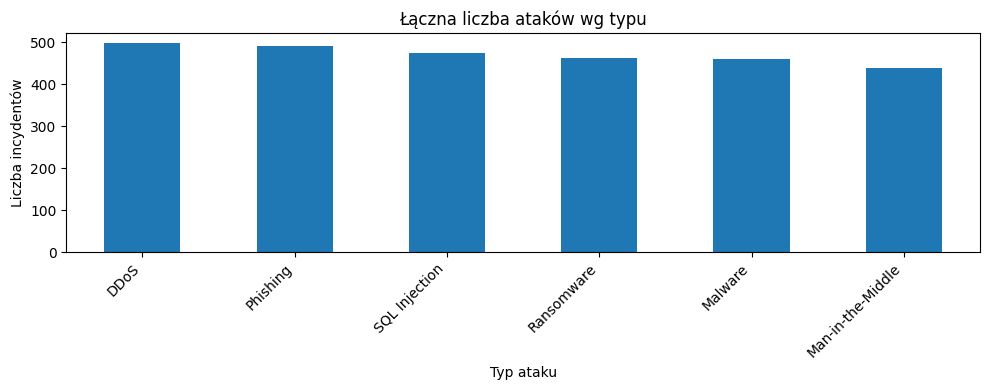

In [14]:
attacks_by_type = df_csv.groupby(['Year', 'Attack Type']).size().unstack(fill_value=0)

counts = attacks_by_type.sum().sort_values(ascending=False)

plt.figure(figsize=(10,4))
counts.plot(kind='bar')
plt.title('Łączna liczba ataków wg typu')
plt.ylabel('Liczba incydentów')
plt.xlabel('Typ ataku')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

- Najbardziej powszechnym typem ataku w całym okresie obserwacji był DDoS (498 ataków).
- Niewiele mniej występowały ataki typu Phishing (491) oraz SQL Injection (474).
- Najrzadziej występowały ataki typu Man-in-the-Middle (438 ataków), jednak różnica względem pozostałych kategorii nie jest znacząca.
- Można zatem stwierdzić, że wszystkie główne typy ataków występują w podobnej skali, żadna kategoria nie dominowała.

### Czy istnieją zależności między miejscem ataku, podmiotem atakującym, typem ataku i celem ataku?

Najczęstsze kombinacje Country x Attack Source:


Country    Attack Source
Japan      Nation-state     92
UK         Hacker Group     83
Brazil     Unknown          80
India      Insider          79
Russia     Nation-state     77
France     Unknown          76
           Nation-state     76
UK         Nation-state     76
India      Unknown          75
Germany    Nation-state     75
Australia  Insider          75
Russia     Insider          74
UK         Unknown          74
Australia  Nation-state     74
USA        Insider          74
Australia  Unknown          73
China      Nation-state     73
Brazil     Hacker Group     73
           Nation-state     72
China      Insider          72
Japan      Insider          71
USA        Nation-state     69
           Unknown          69
France     Insider          69
Germany    Insider          69
China      Unknown          69
Russia     Unknown          68
Brazil     Insider          68
UK         Insider          66
Japan      Unknown          66
France     Hacker Group     65
India      Nat

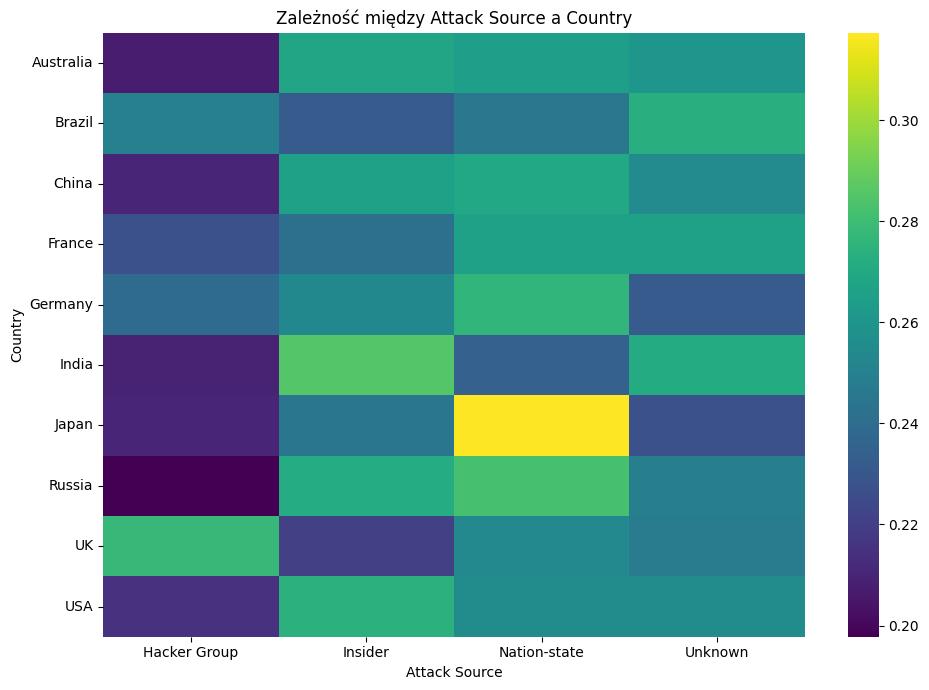

Najczęstsze kombinacje Country x Attack Type:


Country    Attack Type      
Brazil     DDoS                 60
UK         Phishing             59
France     Phishing             58
Australia  Malware              57
Germany    SQL Injection        57
USA        DDoS                 57
Russia     Ransomware           56
Brazil     SQL Injection        56
Australia  DDoS                 55
Japan      Phishing             54
India      Ransomware           54
Japan      Man-in-the-Middle    54
Russia     DDoS                 53
France     SQL Injection        53
India      SQL Injection        51
USA        Phishing             51
           Ransomware           51
UK         DDoS                 50
China      Ransomware           50
Japan      SQL Injection        50
France     Ransomware           49
Brazil     Phishing             49
UK         Malware              49
           Man-in-the-Middle    48
Japan      DDoS                 48
Brazil     Malware              48
China      Phishing             48
Germany    Man-in-the-Midd

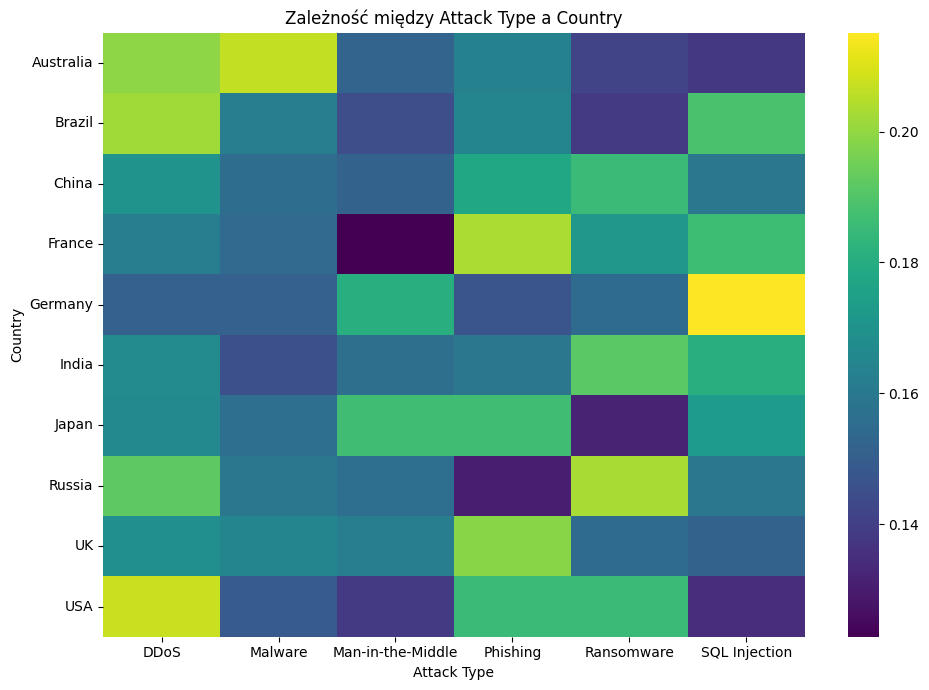

Najczęstsze kombinacje Country x Target Industry:


Country    Target Industry   
UK         IT                    53
           Banking               53
Australia  Healthcare            50
Russia     Telecommunications    49
India      IT                    49
                                 ..
UK         Education             32
USA        Healthcare            31
Germany    Education             28
Russia     Retail                26
France     Telecommunications    23
Length: 70, dtype: int64

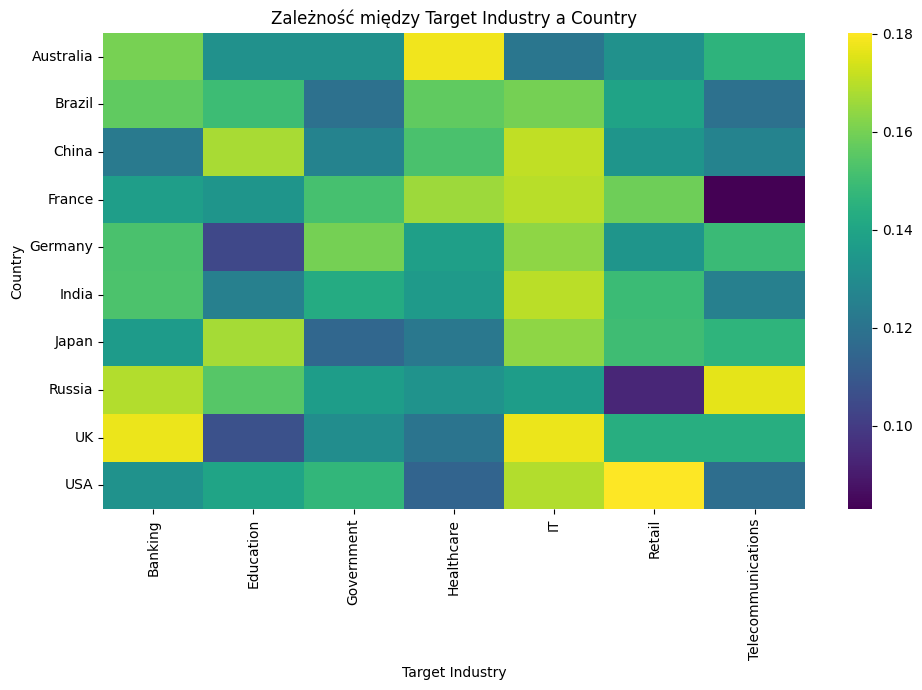

Najczęstsze kombinacje Attack Source x Attack Type:


Attack Source  Attack Type      
Insider        DDoS                 139
Nation-state   SQL Injection        133
Unknown        SQL Injection        130
Nation-state   Phishing             128
               Man-in-the-Middle    127
               DDoS                 126
Unknown        Ransomware           126
               Phishing             124
Insider        SQL Injection        121
Nation-state   Ransomware           118
Hacker Group   Phishing             118
Insider        Phishing             118
Nation-state   Malware              117
Unknown        DDoS                 117
Insider        Ransomware           115
               Malware              115
Hacker Group   DDoS                 112
Unknown        Malware              110
Hacker Group   Ransomware           110
               Malware              107
Unknown        Man-in-the-Middle    107
Insider        Man-in-the-Middle    106
Hacker Group   Man-in-the-Middle    100
               SQL Injection         89
dtype: 

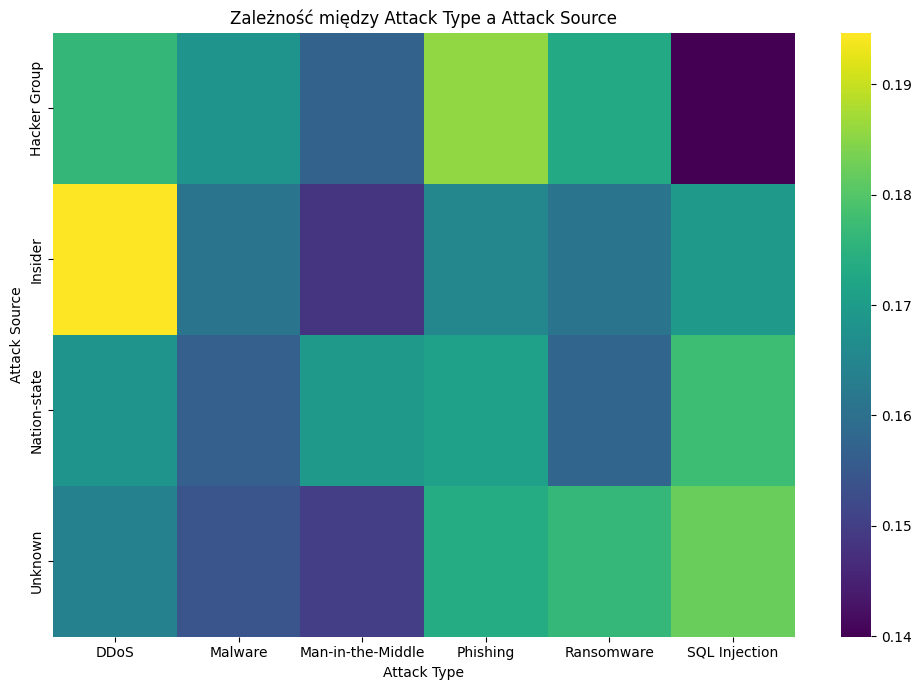

Najczęstsze kombinacje Attack Source x Target Industry:


Attack Source  Target Industry   
Unknown        IT                    139
Insider        Banking               122
               Education             119
Nation-state   Education             117
               Retail                117
               Banking               114
               IT                    109
Unknown        Healthcare            108
               Retail                105
Nation-state   Telecommunications    104
Insider        IT                    104
Hacker Group   IT                    100
Insider        Healthcare            100
Unknown        Government             97
Nation-state   Government             97
               Healthcare             96
Hacker Group   Healthcare             95
Insider        Telecommunications     94
               Government             93
Hacker Group   Government             92
Unknown        Banking                92
Hacker Group   Retail                 92
               Banking                90
Insider        Retail  

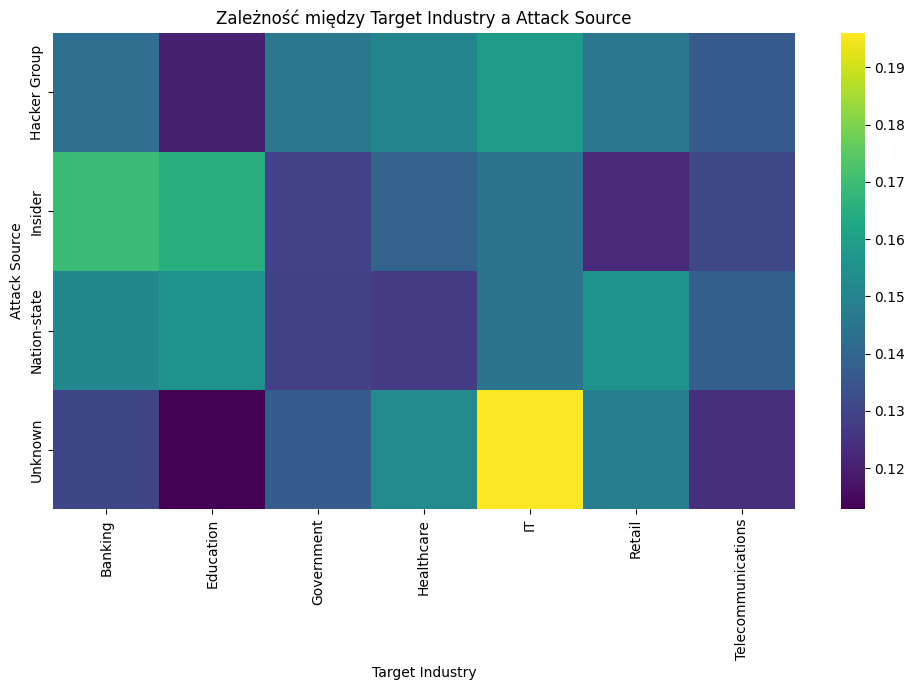

Najczęstsze kombinacje Attack Type x Target Industry:


Attack Type        Target Industry   
Phishing           Banking               89
                   IT                    86
DDoS               Telecommunications    83
                   IT                    83
Phishing           Retail                82
Man-in-the-Middle  IT                    77
DDoS               Healthcare            75
Man-in-the-Middle  Banking               74
Malware            Healthcare            73
Ransomware         Healthcare            73
SQL Injection      IT                    73
                   Telecommunications    71
                   Government            70
                   Healthcare            70
DDoS               Education             70
Ransomware         Government            69
Malware            Telecommunications    69
Ransomware         Education             68
                   IT                    68
SQL Injection      Banking               68
                   Education             66
Man-in-the-Middle  Retail             

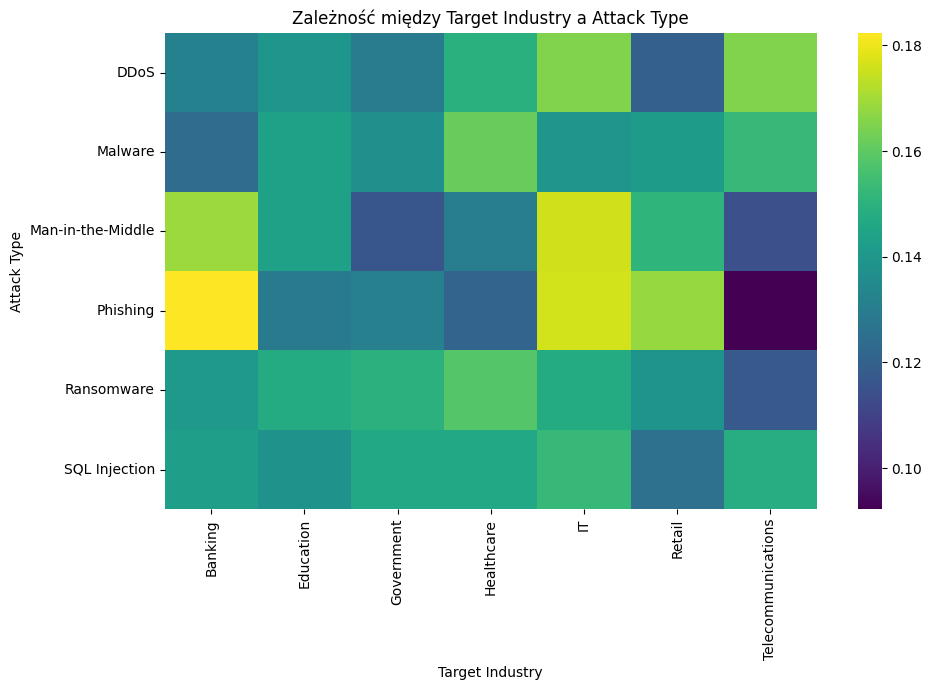

In [ ]:
pairs = [
    ('Country','Attack Source'),
    ('Country','Attack Type'),
    ('Country','Target Industry'),
    ('Attack Source','Attack Type'),
    ('Attack Source','Target Industry'),
    ('Attack Type','Target Industry'),
]
for a,b in pairs:
    print(f'Najczęstsze kombinacje {a} x {b}:')
    display(df_csv.groupby([a,b]).size().sort_values(ascending=False))
    ct = pd.crosstab(df_csv[a], df_csv[b])
    plt.figure(figsize=(10,7))
    sns.heatmap(ct.apply(lambda x: x/x.sum(), axis=1), cmap='viridis')
    plt.title(f'Zależność między {b} a {a}')
    plt.tight_layout()
    plt.show()

#### Country x Attack Source
- Źródła ataków różnią się między krajami, jednak dominują podobne kategorie (Nation-state, Unknown).
- UK jest krajem który grupy hakerskie atakują najczęściej, a Japonia jest krajem najczęściej atakowanym przez inne państwa (Nation-state).

#### Country x Attack Type
- Rozkład jest stosunkowo równomierny, każdy kraj doświadcza różnych typów ataków bez wyraźnej dominacji jednego typu.

#### Country x Target Industry
- Nie widać silnej zależności, jednak niektóre sektory (IT, Banking) pojawiają się częściej w wielu krajach (wcześniej ustalilśmy, że są to sektory najbardziej narażone na ataki).

#### Attack Source x Attack Type
Istnieją pewne zależności, m.in.:
- Insider częściej generuje ataki DDoS,
- Hacker Group koncentruje się na Phishingu,
- Unknown jest najbardziej rozproszoną kategorią.
Może to wskazywać na częściowe powiązanie między źródłem ataku a jego typem, jednak nie jest to regułą.

#### Attack Source x Target Industry
- Insiderzy częściej atakują Banking i Education,
- IT jest atakowane przez różne źródła, dużo nieznanych.

#### Attack Type x Target Industry
Widoczne są pewne zależności, m.in:
- Phishing najczęściej atakuje sektor Banking oraz IT,
- DDoS często występuje w sektorach Telecommunications i IT,
- Man-in-the-Middle jest częsty w sektorach Banking oraz IT, podobnie jak wyżej wymieniony Phishing.
Oznacza to, że niektóre typy ataków mają preferowane cele - może to wynikać z podatności na ataki systemów/procesów w danych sektorach.

### Czy z danych wynika że lepiej dla atakującego, aby atak trwał jak najdłużej, czy aby zaatakować jak najwięcej użytkowników?

Liczba wierszy użytych do korelacji: 2746
Korelacja (time vs users): 0.004455964172733103
Korelacja (time vs loss): -0.015300268867884475


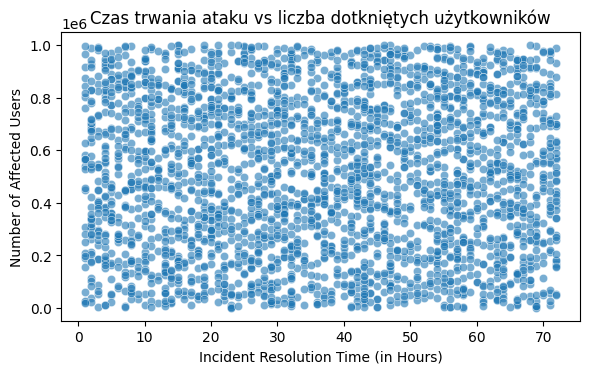

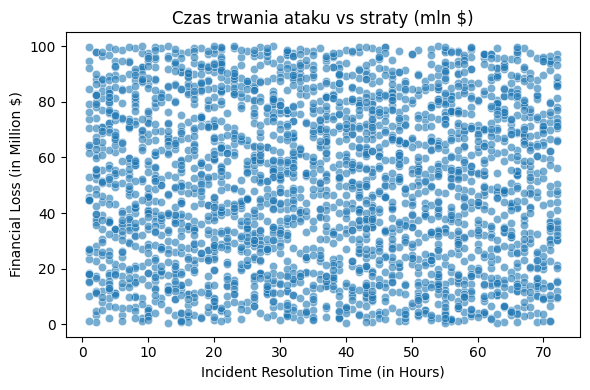

In [ ]:
cols = ['Incident Resolution Time (in Hours)','Number of Affected Users','Financial Loss (in Million $)']
sub = df_csv[cols].dropna()
print('Liczba wierszy użytych do korelacji:', len(sub))
print('Korelacja (time vs users):', sub['Incident Resolution Time (in Hours)'].corr(sub['Number of Affected Users']))
print('Korelacja (time vs loss):', sub['Incident Resolution Time (in Hours)'].corr(sub['Financial Loss (in Million $)']))
plt.figure(figsize=(6,4))
sns.scatterplot(x='Incident Resolution Time (in Hours)', y='Number of Affected Users', data=sub, alpha=0.6)
plt.title('Czas trwania ataku vs liczba dotkniętych użytkowników')
plt.tight_layout()
plt.show()
plt.figure(figsize=(6,4))
sns.scatterplot(x='Incident Resolution Time (in Hours)', y='Financial Loss (in Million $)', data=sub, alpha=0.6)
plt.title('Czas trwania ataku vs straty (mln $)')
plt.tight_layout()
plt.show()

Wyniki sugerują, że wydłużanie czasu trwania ataku nie przekłada się zauważalnie na większe straty finansowe ani większą liczbę poszkodowanych użytkowników (bardzo niska korelacja).
Z perspektywy atakującego bardziej efektywne może być zwiększenie skali ataku (liczby użytkowników), niż czasu jego trwania.

### Jak rozkłada się częstotliwość ataków na przestrzeni lat? Czy tendencja jest spadkowa czy wręcz przeciwnie?

Liczba incydentów wg roku:


Year
2015    267
2016    273
2017    308
2018    299
2019    259
2020    308
2021    289
2022    313
2023    306
2024    294
Name: count, dtype: int64

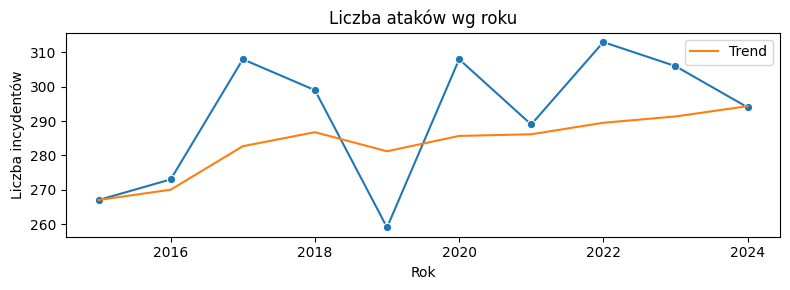

In [ ]:
year_counts = df_csv['Year'].dropna().astype(int).value_counts().sort_index()
print('Liczba incydentów wg roku:')
display(year_counts)
plt.figure(figsize=(8,3))
sns.lineplot(x=year_counts.index, y=year_counts.values, marker='o')
plt.title('Liczba ataków wg roku')
plt.xlabel('Rok')
plt.ylabel('Liczba incydentów')
plt.plot(year_counts.index, pd.Series(year_counts.values).rolling(9, min_periods=1).mean(), label='Trend')
plt.legend()
plt.tight_layout()
plt.show()

Liczba ataków w poszczególnych latach utrzymuje się na względnie stałym poziomie. Od roku 2020 ataków było więcej niż w poprzednich latach, można by więc stwierdzić że tendencja jest lekko wzrostowa, jednak nie jest to silna monotoniczna tendencja, bo liczba ataków oscyluje wokół podobnych wartości w całym okresie.